# Signal Audit Analysis

This notebook loads an exported browser signal-audit JSON file and gives a quick diagnostic view of:
- session metadata and capabilities
- event counts by kind
- field support and whether values look constant or informative
- simple plots for motion, orientation, touch/pointer, and event timing


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


## 1. Choose JSON file

Set `JSON_PATH` to the exported audit file you want to inspect.

In [2]:
JSON_PATH = Path('signal_audit_d3355b30-0097-4a5d-ba1c-0d44f3d50898.json')
assert JSON_PATH.exists(), f'File not found: {JSON_PATH.resolve()}'

with JSON_PATH.open('r', encoding='utf-8') as f:
    payload = json.load(f)

events = pd.DataFrame(payload.get('events', []))
events.head()

,kind,tsIso,tRelMs,zone,scrollTop,scrollHeight,clientHeight,ax,ay,az,agx,agy,agz,rotAlpha,rotBeta,rotGamma,interval,alpha,beta,gamma,absolute,pointerType,pointerId,isPrimary,x,y,pressure,width,height,tiltX,tiltY,twist,force,radiusX,radiusY,rotationAngle,relativeX,relativeY,keyClass,code,repeat,inputType,dataLength,valueLength
0,scroll,2026-04-23T15:05:17.488Z,29495,scrollZone,-20.0,644.0,216.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,scroll,2026-04-23T15:05:17.505Z,29512,scrollZone,-18.0,644.0,216.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,scroll,2026-04-23T15:05:17.522Z,29529,scrollZone,-16.0,644.0,216.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,scroll,2026-04-23T15:05:17.538Z,29545,scrollZone,-14.0,644.0,216.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,scroll,2026-04-23T15:05:17.554Z,29562,scrollZone,-12.0,644.0,216.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Session summary


In [3]:
capabilities = pd.Series(payload.get('capabilities', {}), name='value')
permissions = pd.Series(payload.get('permissions', {}), name='value')

print('startedAtIso:', payload.get('startedAtIso'))
print('auditSessionId:', payload.get('auditSessionId'))
print('n_events:', len(events))
print('event columns:', len(events.columns))

display(capabilities.to_frame('capability'))
display(permissions.to_frame('permission'))

startedAtIso: 2026-04-23T15:04:47.993Z
auditSessionId: d3355b30-0097-4a5d-ba1c-0d44f3d50898
n_events: 5000
event columns: 44


,capability
auditSessionId,d3355b30-0097-4a5d-ba1c-0d44f3d50898
capturedAtIso,2026-04-23T15:04:45.312Z
userAgent,Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like M...
platform,iPhone
language,en-GB
cookieEnabled,True
onLine,True
maxTouchPoints,5
pointerEventSupported,True
touchEventSupported,True


,permission
motion,granted


## 3. Event counts


In [4]:
event_counts = events['kind'].value_counts().rename_axis('kind').reset_index(name='count')
event_counts

,kind,count
0,devicemotion,1829
1,deviceorientation,1829
2,pointermove,333
3,touchmove,315
4,drag_move,296
5,keydown,70
6,beforeinput,70
7,input,70
8,keyup,70
9,pointerdown,18


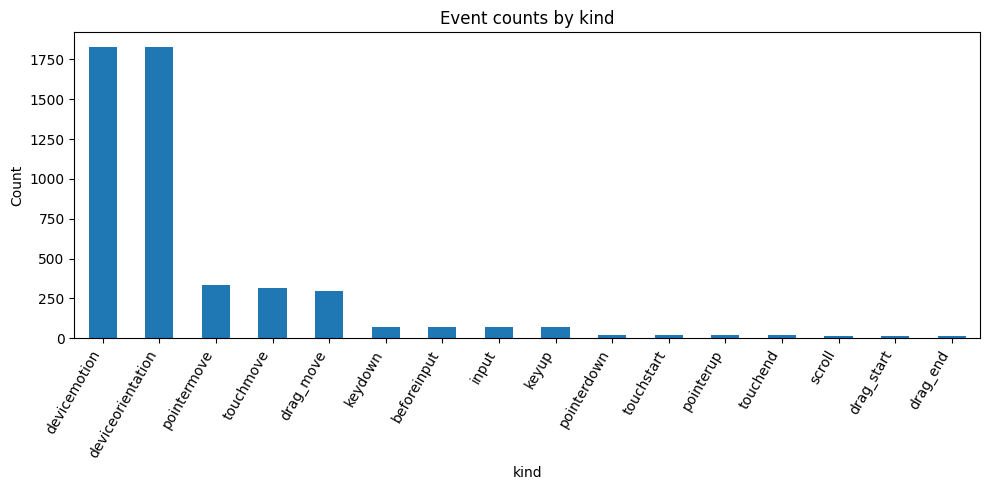

In [5]:
plt.figure(figsize=(10, 5))
event_counts.plot(kind='bar', x='kind', y='count', legend=False, ax=plt.gca())
plt.title('Event counts by kind')
plt.ylabel('Count')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

## 4. Field support audit

This checks selected fields for support, non-null coverage, uniqueness, and whether values appear effectively constant.

In [6]:
FIELDS_TO_AUDIT = [
    'pointerType', 'pressure', 'width', 'height', 'force', 'radiusX', 'radiusY', 'rotationAngle',
    'ax', 'ay', 'az', 'agx', 'agy', 'agz', 'rotAlpha', 'rotBeta', 'rotGamma',
    'alpha', 'beta', 'gamma', 'scrollTop', 'valueLength'
]

def field_summary(df, field):
    if field not in df.columns:
        return {
            'field': field,
            'present': False,
            'non_null': 0,
            'null': len(df),
            'n_unique_non_null': 0,
            'numeric_min': None,
            'numeric_max': None,
            'numeric_std': None,
            'sample_values': []
        }

    s = df[field]
    non_null = s.dropna()
    numeric = pd.to_numeric(non_null, errors='coerce').dropna()

    return {
        'field': field,
        'present': True,
        'non_null': int(non_null.notna().sum()),
        'null': int(s.isna().sum()),
        'n_unique_non_null': int(non_null.astype(str).nunique()),
        'numeric_min': float(numeric.min()) if len(numeric) else None,
        'numeric_max': float(numeric.max()) if len(numeric) else None,
        'numeric_std': float(numeric.std()) if len(numeric) > 1 else None,
        'sample_values': non_null.astype(str).unique()[:8].tolist()
    }

audit_df = pd.DataFrame([field_summary(events, field) for field in FIELDS_TO_AUDIT])
audit_df

,field,present,non_null,null,n_unique_non_null,numeric_min,numeric_max,numeric_std,sample_values
0,pointerType,True,695,4305,1,NaN,NaN,NaN,[touch]
1,pressure,True,695,4305,1,0.000,0.000,0.000000,[0.0]
2,width,True,695,4305,3,0.000,72.623,14.658464,"[48.416, 0.0, 72.623]"
3,height,True,695,4305,3,0.000,72.623,14.658464,"[48.416, 0.0, 72.623]"
4,force,True,351,4649,2,0.000,24.208,5.347240,"[24.208, 0.0]"
5,radiusX,True,351,4649,1,24.208,24.208,0.000000,[24.208]
6,radiusY,True,351,4649,1,0.000,0.000,0.000000,[0.0]
7,rotationAngle,True,351,4649,1,0.000,0.000,0.000000,[0.0]
8,ax,True,1829,3171,869,-1.033,1.421,0.280729,"[0.073, -0.385, -0.383, -0.148, -0.006, 0.361,..."
9,ay,True,1829,3171,639,-1.574,1.132,0.180799,"[-0.121, -0.216, -0.173, -0.082, -0.007, 0.016..."


## 5. Event timing density


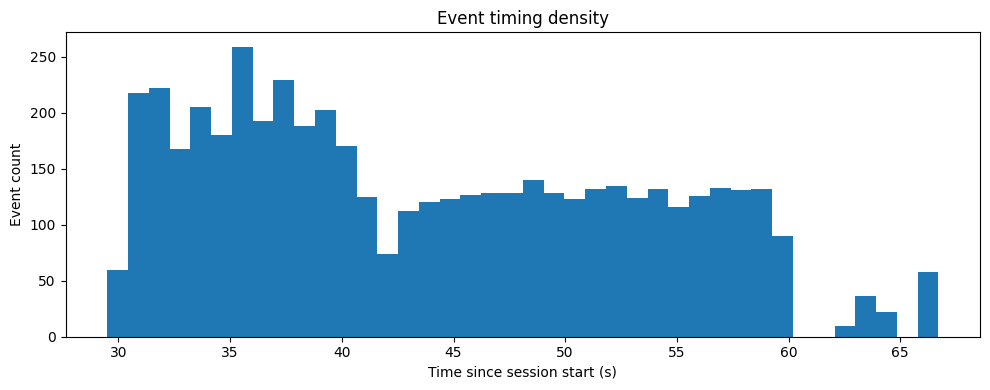

In [7]:
if 'tRelMs' in events.columns:
    plt.figure(figsize=(10, 4))
    plt.hist(events['tRelMs'].dropna() / 1000.0, bins=40)
    plt.title('Event timing density')
    plt.xlabel('Time since session start (s)')
    plt.ylabel('Event count')
    plt.tight_layout()
    plt.show()
else:
    print('tRelMs not present')

## 6. Motion plots


In [8]:
motion = events[events['kind'] == 'devicemotion'].copy()
motion[['tRelMs', 'ax', 'ay', 'az', 'agx', 'agy', 'agz', 'rotAlpha', 'rotBeta', 'rotGamma']].head()

,tRelMs,ax,ay,az,agx,agy,agz,rotAlpha,rotBeta,rotGamma
16,30068,0.073,-0.121,-0.621,0.983,-8.537,-5.571,17.181,15.364,2.213
18,30082,-0.385,-0.216,-0.560,0.540,-8.649,-5.479,19.595,31.552,6.169
20,30095,-0.383,-0.173,0.180,0.586,-8.645,-4.664,22.356,46.636,10.156
22,30112,-0.148,-0.082,0.075,0.864,-8.598,-4.682,26.031,39.200,11.107
24,30130,-0.006,-0.007,-0.003,1.018,-8.547,-4.713,28.015,32.699,13.979


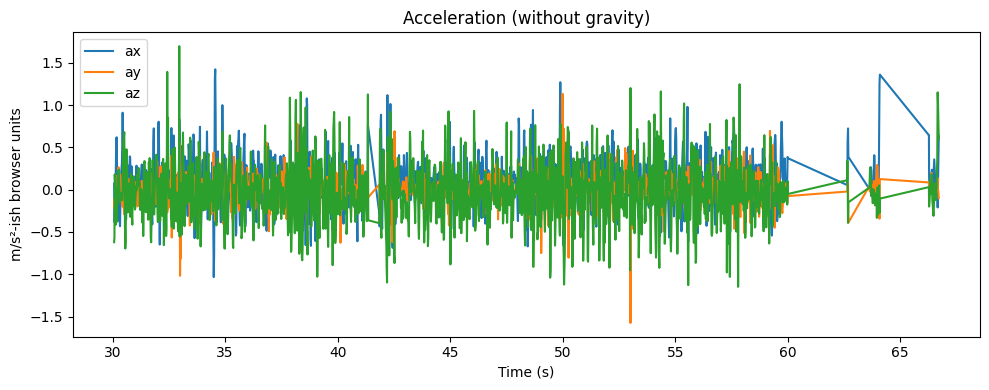

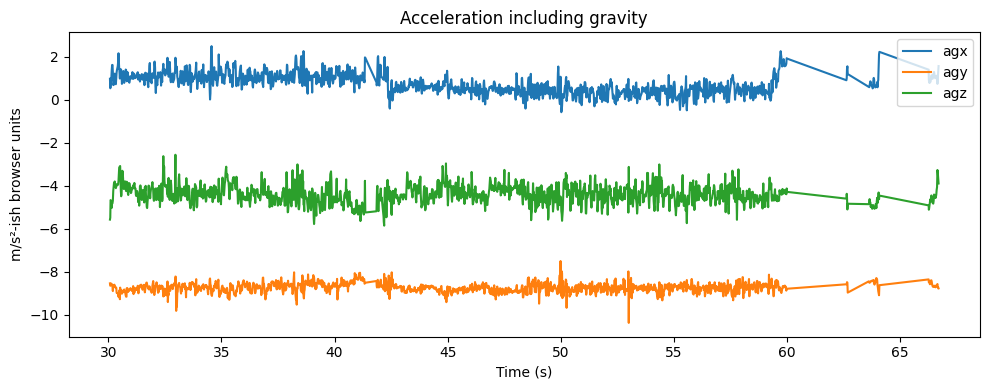

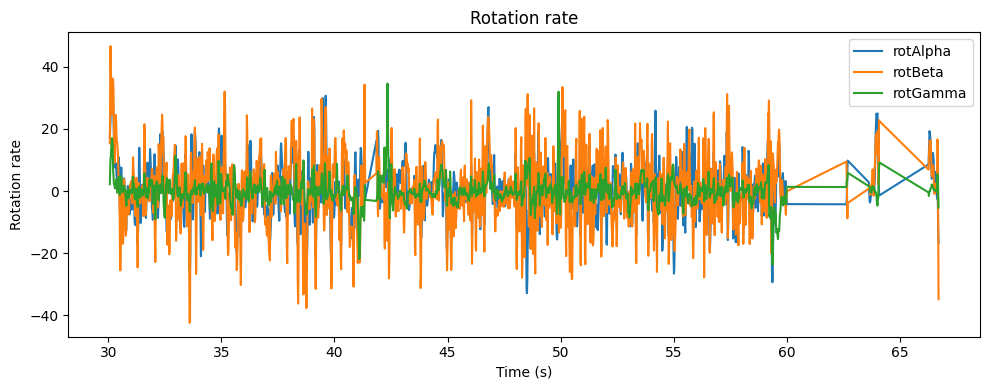

In [9]:
if not motion.empty:
    t = motion['tRelMs'] / 1000.0

    plt.figure(figsize=(10, 4))
    plt.plot(t, motion['ax'], label='ax')
    plt.plot(t, motion['ay'], label='ay')
    plt.plot(t, motion['az'], label='az')
    plt.title('Acceleration (without gravity)')
    plt.xlabel('Time (s)')
    plt.ylabel('m/s²-ish browser units')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t, motion['agx'], label='agx')
    plt.plot(t, motion['agy'], label='agy')
    plt.plot(t, motion['agz'], label='agz')
    plt.title('Acceleration including gravity')
    plt.xlabel('Time (s)')
    plt.ylabel('m/s²-ish browser units')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t, motion['rotAlpha'], label='rotAlpha')
    plt.plot(t, motion['rotBeta'], label='rotBeta')
    plt.plot(t, motion['rotGamma'], label='rotGamma')
    plt.title('Rotation rate')
    plt.xlabel('Time (s)')
    plt.ylabel('Rotation rate')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No devicemotion events found')

## 7. Orientation plots


In [10]:
orientation = events[events['kind'] == 'deviceorientation'].copy()
orientation[['tRelMs', 'alpha', 'beta', 'gamma']].head()

,tRelMs,alpha,beta,gamma
17,30074,347.235,59.117,10.426
19,30087,347.250,59.306,10.651
21,30097,347.434,59.754,11.309
23,30116,347.649,60.267,12.015
25,30135,347.781,60.558,12.260


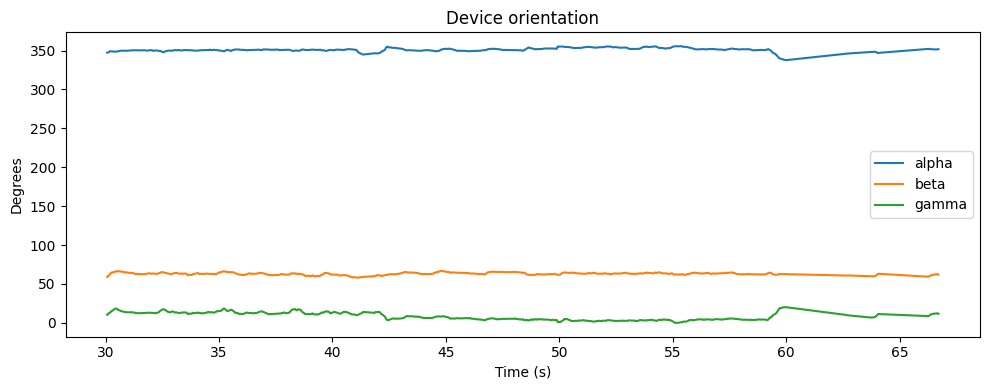

In [11]:
if not orientation.empty:
    t = orientation['tRelMs'] / 1000.0
    plt.figure(figsize=(10, 4))
    plt.plot(t, orientation['alpha'], label='alpha')
    plt.plot(t, orientation['beta'], label='beta')
    plt.plot(t, orientation['gamma'], label='gamma')
    plt.title('Device orientation')
    plt.xlabel('Time (s)')
    plt.ylabel('Degrees')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No deviceorientation events found')

## 8. Touch / pointer contact fields


In [12]:
touch_pointer = events[events['kind'].isin(['pointerdown', 'pointermove', 'pointerup', 'touchstart', 'touchmove', 'touchend'])].copy()
touch_pointer[['kind', 'pointerType', 'pressure', 'width', 'height', 'force', 'radiusX', 'radiusY', 'rotationAngle']].head(20)

,kind,pointerType,pressure,width,height,force,radiusX,radiusY,rotationAngle
65,pointerdown,touch,0.0,48.416,48.416,NaN,NaN,NaN,NaN
66,touchstart,NaN,NaN,NaN,NaN,24.208,24.208,0.0,0.0
72,pointermove,touch,0.0,48.416,48.416,NaN,NaN,NaN,NaN
73,touchmove,NaN,NaN,NaN,NaN,0.000,24.208,0.0,0.0
75,pointermove,touch,0.0,48.416,48.416,NaN,NaN,NaN,NaN
79,pointermove,touch,0.0,48.416,48.416,NaN,NaN,NaN,NaN
80,touchmove,NaN,NaN,NaN,NaN,0.000,24.208,0.0,0.0
84,pointermove,touch,0.0,48.416,48.416,NaN,NaN,NaN,NaN
85,touchmove,NaN,NaN,NaN,NaN,0.000,24.208,0.0,0.0
89,pointermove,touch,0.0,48.416,48.416,NaN,NaN,NaN,NaN


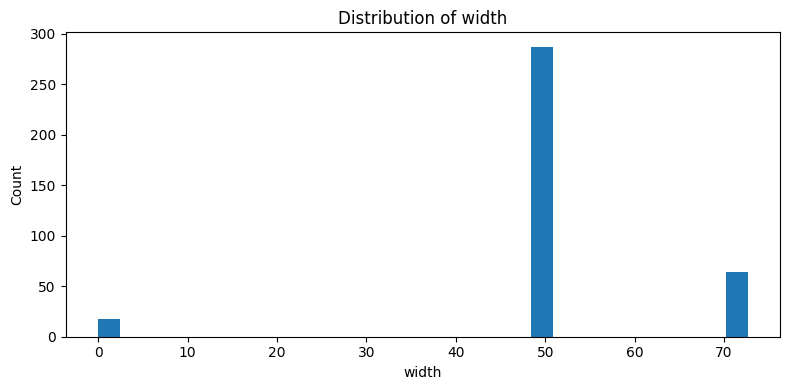

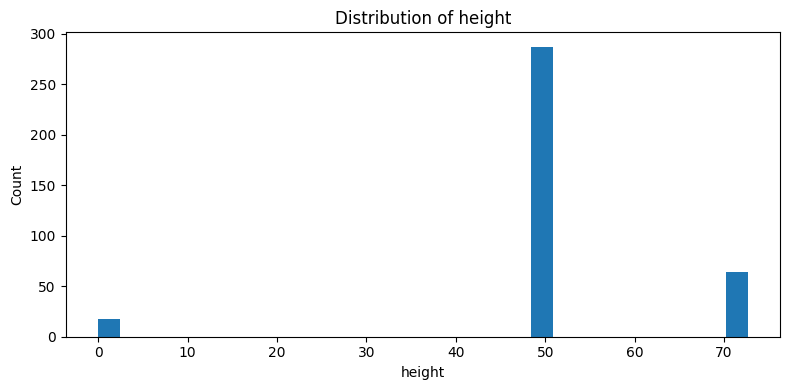

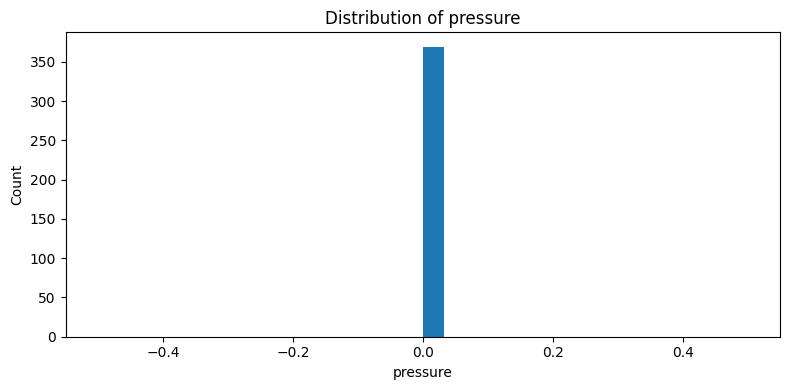

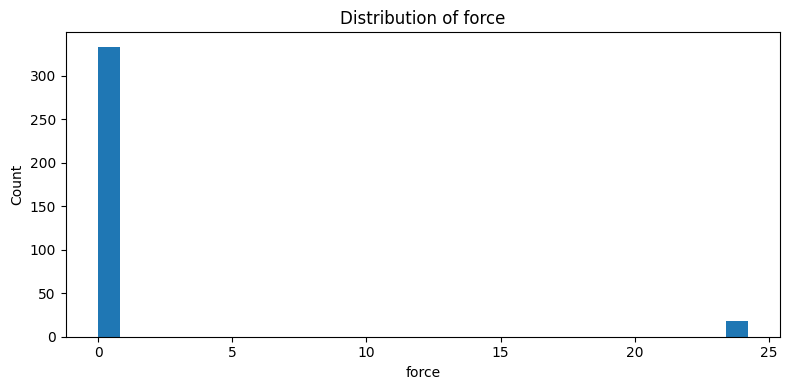

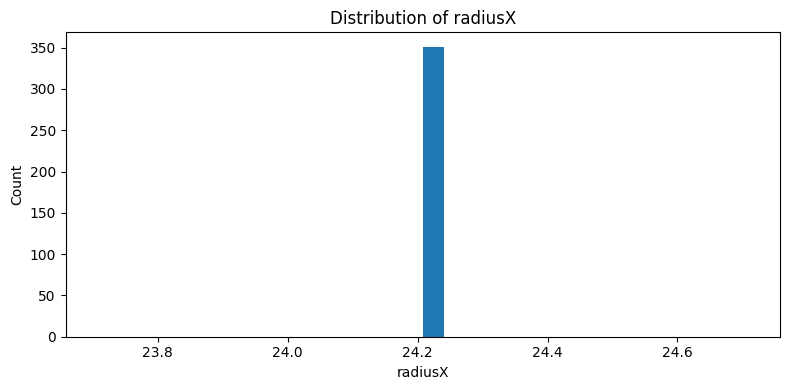

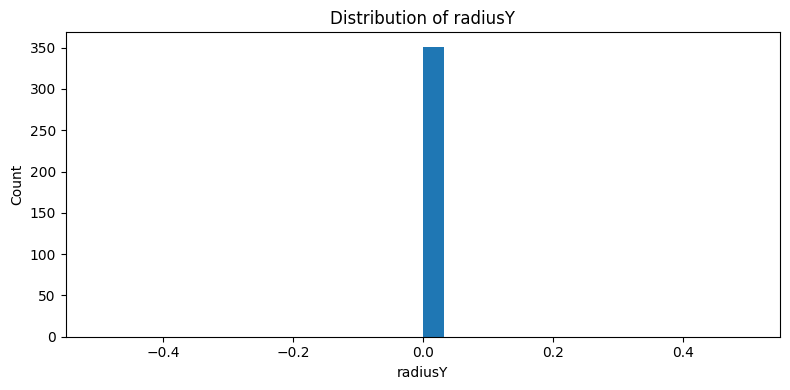

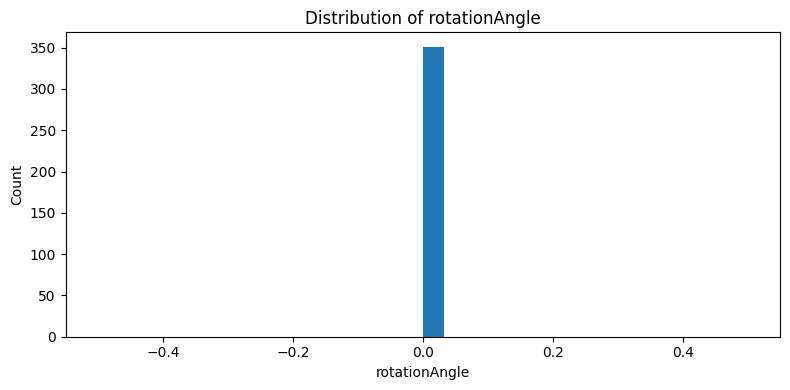

In [13]:
for field in ['width', 'height', 'pressure', 'force', 'radiusX', 'radiusY', 'rotationAngle']:
    if field in touch_pointer.columns and touch_pointer[field].notna().any():
        plt.figure(figsize=(8, 4))
        plt.hist(pd.to_numeric(touch_pointer[field], errors='coerce').dropna(), bins=30)
        plt.title(f'Distribution of {field}')
        plt.xlabel(field)
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()
    else:
        print(f'{field}: no usable values found')

## 9. Quick conclusions helper


In [14]:
def interpret_field(row):
    if not row['present']:
        return 'missing'
    if row['non_null'] == 0:
        return 'all null'
    if row['n_unique_non_null'] <= 1:
        return 'constant or near-constant'
    if row['numeric_std'] is not None and row['numeric_std'] == 0:
        return 'constant numeric'
    return 'varies'

quick_conclusions = audit_df[['field']].copy()
quick_conclusions['interpretation'] = audit_df.apply(interpret_field, axis=1)
quick_conclusions

,field,interpretation
0,pointerType,constant or near-constant
1,pressure,constant or near-constant
2,width,varies
3,height,varies
4,force,varies
5,radiusX,constant or near-constant
6,radiusY,constant or near-constant
7,rotationAngle,constant or near-constant
8,ax,varies
9,ay,varies
